# Разведочный анализ данных 

Исследуем что влияет на популярность трека, проверим данные на качество и подготовим их для обучения модели

## Загрузка Датасета

In [333]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [334]:
df = pd.read_csv('spotify-tracks-dataset-detailed.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

## Очистка признаков

**1. Проверим что признак 'track_id' является уникальным**

Надо проверить, что в столбце кол-во дубликаторв равно 0

In [335]:
df['track_id'].duplicated().sum()

24259

К сожалению, составители датасета нас обманули и track_id не уникален.

Посмотрим на записи которые повторяются по 'track_id'

In [336]:
list_of_track_id_dupl = df[df['track_id'].duplicated()]['track_id'].to_list()
len(list_of_track_id_dupl)

24259

In [337]:
dupl_track_id = df[df['track_id'].isin(list_of_track_id_dupl)]
print(len(dupl_track_id))

dupl_track_id.head(5)

40900


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic


Проверим являются ли эти строки полными дубликатами по всем столбцам, для этого используем метод duplicated, но с параметром keep=False: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html

In [338]:
df.duplicated().sum()

450

Удалим 450 полных дубликата

In [339]:
size_defore = len(df)
print(f'кол-во строк до отчистки: {size_defore}')

df.drop_duplicates(inplace=True)

size_after = len(df)
print(f'кол-во строк до отчистки: {size_after}')

print(f'Было удалено {size_defore - size_after} строк')

кол-во строк до отчистки: 114000
кол-во строк до отчистки: 113550
Было удалено 450 строк


Посмотрим на данные с одинаковым 'track_id'

In [340]:
dupl_track_id = df[df['track_id'].isin(list_of_track_id_dupl)].sort_values(by='track_id')
print(len(dupl_track_id))

dupl_track_id.head(20)

40450


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,0,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


Проверим сколько дубликатов имеет расхождение в названии исполнителя (по логике такого быть не должно).

In [341]:
check_dupl_atrist_name = dupl_track_id.groupby('track_id')['artists'].nunique()
(check_dupl_atrist_name > 1).sum()

0

Имена артистов совпадает внутри дубликатов.

Теперь проверим название альбомов.

In [342]:
check_dupl_album_name = dupl_track_id.groupby('track_id')['album_name'].nunique()
check_dupl_album_name 

track_id
001APMDOl3qtx1526T11n1    1
001YQlnDSduXd5LgBd66gT    1
003vvx7Niy0yvhvHt4a68B    1
004h8smbIoAkUNDJvVKwkG    1
006rHBBNLJMpQs8fRC2GDe    1
                         ..
7ztSVy67w9rXpKg5L2zN5l    1
7zubR9uYAWjb5KPZTMm85e    1
7zumacGldlmxpoP8bpaeLe    1
7zv2vmZq8OjS54BxFzI2wM    1
7zwn1eykZtZ5LODrf7c0tS    1
Name: album_name, Length: 16641, dtype: int64

Название альбома также везде совпадает.

Анализом через вывод датасета заметили расхождение в жанрах - проверим.

In [343]:
check_dupl_genre_name = dupl_track_id.groupby('track_id')['track_genre'].nunique()
(check_dupl_genre_name > 1).sum()

16299

16299 строк дубликатов, в которых различается жанр. Посмотрим на эти строки, особенно важно обратить внимание на целевую переменную 'popularity'.

In [344]:
track_id_genre_non_similar = check_dupl_genre_name[check_dupl_genre_name > 1].index.to_list()

dupl_track_id[dupl_track_id['track_id'].isin(track_id_genre_non_similar)][['track_id', 'track_genre', 'popularity']]

,track_id,track_genre,popularity
103211,001APMDOl3qtx1526T11n1,soul,0
15028,001APMDOl3qtx1526T11n1,chill,0
85578,001YQlnDSduXd5LgBd66gT,punk-rock,38
100420,001YQlnDSduXd5LgBd66gT,ska,38
3257,003vvx7Niy0yvhvHt4a68B,alternative,86
...,...,...,...
72679,7zv2vmZq8OjS54BxFzI2wM,metalcore,25
22326,7zv2vmZq8OjS54BxFzI2wM,death-metal,25
91401,7zwn1eykZtZ5LODrf7c0tS,rock,83
3100,7zwn1eykZtZ5LODrf7c0tS,alternative,83


In [345]:
popularity_gengre_analysis = dupl_track_id[dupl_track_id['track_id'].isin(track_id_genre_non_similar)].groupby('track_id')['popularity'].nunique()
(popularity_gengre_analysis > 1).sum()

720

В 720 записях расходятся показания популярности. Оставим только максимальный, поскольку наша задача в дальнейшем оценить именно максимальный потенциал трека.

In [346]:
for column_name in dupl_track_id.columns.to_list():
    check_all = dupl_track_id.groupby('track_id')[column_name].nunique()
    if (check_all > 1).sum() > 0:
        print(f'В столбце {column_name} расходятся значения для одинаковых значений "track_id"')

В столбце popularity расходятся значения для одинаковых значений "track_id"
В столбце track_genre расходятся значения для одинаковых значений "track_id"


Посмотрим на распределение 'popularity' до и после удаление дублей по полю 'track_id'.

In [347]:
dupl_track_id_to_first_graph = dupl_track_id.copy()

index_of_max_popularity = dupl_track_id.groupby('track_id')['popularity'].idxmax()
dupl_track_id = dupl_track_id.loc[index_of_max_popularity]

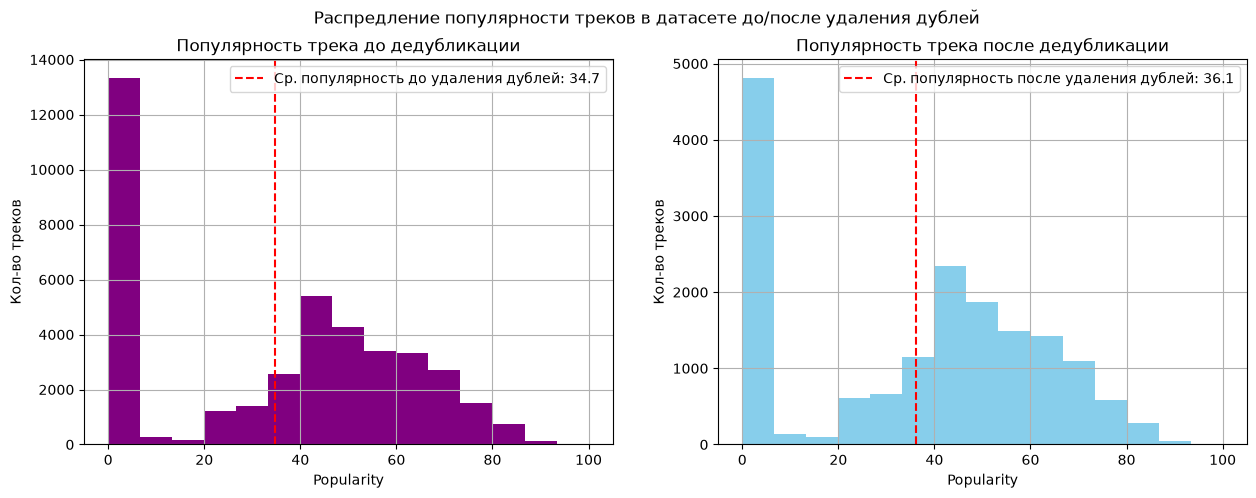

In [348]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(
    dupl_track_id_to_first_graph['popularity'],
    bins=15,
    color='purple'
)
ax[0].set_title('Популярность трека до дедубликации')
ax[0].set_xlabel('Popularity')
ax[0].set_ylabel('Кол-во треков')
ax[0].grid()

ax[0].axvline(
    dupl_track_id_to_first_graph['popularity'].mean(),
    color='red',
    linestyle='--',
    label=f'Ср. популярность до удаления дублей: {dupl_track_id_to_first_graph["popularity"].mean():.1f}'
)
ax[0].legend()


ax[1].hist(
    dupl_track_id['popularity'],
    bins=15,
    color='skyblue'
)
ax[1].set_title('Популярность трека после дедубликации')
ax[1].set_xlabel('Popularity')
ax[1].set_ylabel('Кол-во треков')
ax[1].grid()

ax[1].axvline(
    dupl_track_id['popularity'].mean(),
    color='red',
    linestyle='--',
    label=f'Ср. популярность после удаления дублей: {dupl_track_id["popularity"].mean():.1f}'
)
ax[1].legend()


plt.suptitle('Распредление популярности треков в датасете до/после удаления дублей')
plt.show()

После прочтения документации API-spotify: https://developer.spotify.com/documentation/web-api

Можно заметить, что для одинаковых track_id расходится жанр, album_name (в датасете такого нет, но это возможно), но все музыкальные параметры остаются неизменными (как и имя артиста). Поскольку наша задача - оценка популярности, то из всех track_id возьмем тот, что имеет большую популярность, поскольку это позволит предсказывать максимальный потенциал трека.

Для того чтобы оставить максимальное значение 'popularity' бдуем использовать метод idxmax(), который индекс максимального значения (в нашем случае для сгруппированного по 'track_id').

https://www.geeksforgeeks.org/pandas/python-pandas-series-idxmax/

In [349]:
index_of_max_popularity = dupl_track_id.groupby('track_id')['popularity'].idxmax()
dupl_track_id = dupl_track_id.loc[index_of_max_popularity]

len(dupl_track_id)

16641

Проверим, что очистка датасета прошла успешно.

In [350]:
popularity_gengre_analysis = dupl_track_id[dupl_track_id['track_id'].isin(track_id_genre_non_similar)].groupby('track_id')['popularity'].nunique()
(popularity_gengre_analysis > 1).sum()

0

In [351]:
check_dupl_genre_name = dupl_track_id.groupby('track_id')['track_genre'].nunique()
(check_dupl_genre_name > 1).sum()

0

In [352]:
for column_name in dupl_track_id.columns.to_list():
    check_all = dupl_track_id.groupby('track_id')[column_name].nunique()
    if (check_all > 1).sum() > 0:
        print(f'В столбце {column_name} расходятся значения для одинаковых значений "track_id"')

Отлично, теперь уберем из изначального датасета часть с дубликатами по track_id и присоединим очищенную часть.

In [353]:
print(len(df))

df = df[~df['track_id'].isin(list_of_track_id_dupl)]

print(len(df))

df = pd.concat(
    [df, dupl_track_id],
    ignore_index=True
)

len(df)

113550
73100


89741

In [354]:
df['track_id'].nunique() == len(df)

True

**2. Посмотрим на кол-во пропусков в столбцах**

In [355]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Нашли 1 пропуск в трех столбцах, проверим по 'track_id', что значения раличны и предпримем решение о дальнейших действиях с пропусками.

In [356]:
artist_null = str(df[df['artists'].isna()]['track_id'])
album_name_null = str(df[df['album_name'].isna()]['track_id'])
track_name = str(df[df['track_name'].isna()]['track_id'])

print(artist_null, album_name_null, track_name, sep='\n')
print((artist_null == album_name_null) and (album_name_null == track_name))

43249    1kR4gIb7nGxHPI3D2ifs59
Name: track_id, dtype: object
43249    1kR4gIb7nGxHPI3D2ifs59
Name: track_id, dtype: object
43249    1kR4gIb7nGxHPI3D2ifs59
Name: track_id, dtype: object
True


In [357]:
1/len(df)

1.1143178703156863e-05

Для единственного пропуска в датасете совпадает уникальное значение 'track_id', следовательно это один и тот же трек.

Удалим эту запись, поскольку тогда данные не потеряют в своем качестве (для обучения DL-модели, поскольку 1 строк от 114k состовляет всего около 0.0008%)

In [358]:
size_defore = len(df)
print(f'кол-во строк до отчистки: {size_defore}')

index_to_drop = df[df['artists'].isna()]['track_id'].index
df.drop(index_to_drop, inplace=True)

size_after = len(df)
print(f'кол-во строк до отчистки: {size_after}')

print(f'Было удалено {size_defore - size_after} строк')

кол-во строк до отчистки: 89741
кол-во строк до отчистки: 89740
Было удалено 1 строк


Проверим что удалили пропуски

In [359]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Да, пропусков нет - можно идти дальше

## Анализ целевой переменной

**1. Проведем оценку влияния признаков на целевую переменную: 'popularity'**

In [360]:
df['popularity'].describe()

count    89740.000000
mean        33.207566
std         20.574086
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64

Построим визуализацию, которая описывет основные численные характеристики переменной.

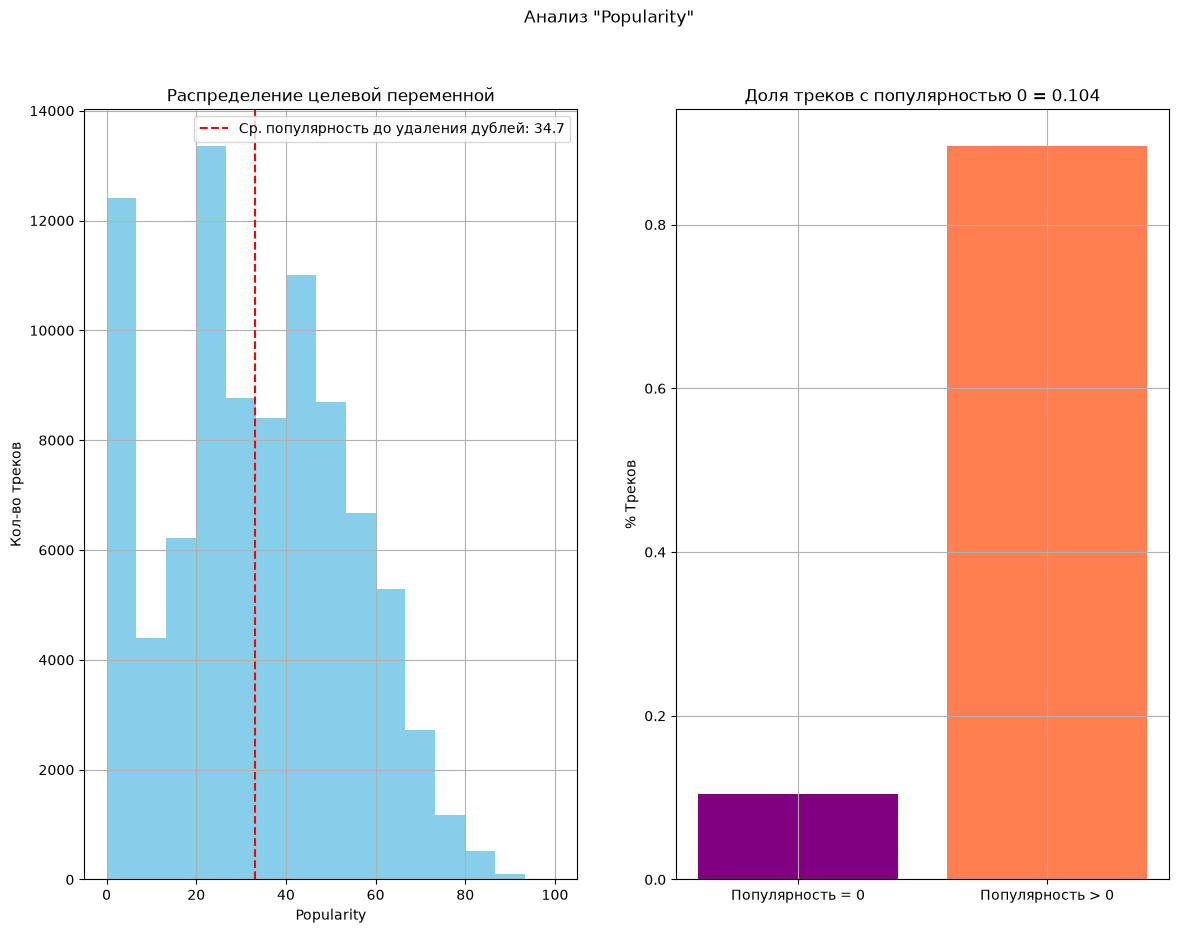

In [361]:
fig, ax = plt.subplots(1, 2, figsize=(14, 10))

ax[0].hist(
    df['popularity'],
    bins=15,
    color='skyblue'
)
ax[0].set_title('Распределение целевой переменной')
ax[0].set_xlabel('Popularity')
ax[0].set_ylabel('Кол-во треков')
ax[0].grid()

ax[0].axvline(
    df['popularity'].mean(),
    color='red',
    linestyle='--',
    label=f'Ср. популярность до удаления дублей: {dupl_track_id_to_first_graph["popularity"].mean():.1f}'
)
ax[0].legend()



popularity_is_zero = (df['popularity'] == 0).mean()

ax[1].bar(
    ['Популярность = 0', 'Популярность > 0'],
    [popularity_is_zero, 1 - popularity_is_zero],
    color=['purple', 'coral']
)
ax[1].set_title(f'Доля треков с популярностью 0 = {popularity_is_zero:.3f}')
ax[1].set_ylabel('% Треков')
ax[1].grid()


plt.suptitle('Анализ "Popularity"')
plt.show()

Доля треков с нулевой состовляет 0.104, что не является значительным отклонением в сторону малозаметных треков - поэтому не нужно отдельно работать с такими записями.

**2. Проведем корреляционный анализ**

Сначала посмотрим влияние числовых переменных на целевую, к ним относятся технические характеристики аудидорожки:

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html

In [362]:
numbers_columns_names = df.select_dtypes('number').columns.to_list()
numbers_columns_names

['popularity',
 'duration_ms',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [363]:
corr_numbers_features = df[numbers_columns_names].corr()['popularity'].drop('popularity').sort_values()
corr_numbers_features

instrumentalness   -0.127647
speechiness        -0.047202
acousticness       -0.038820
duration_ms        -0.023155
mode               -0.016385
liveness           -0.013968
valence            -0.011546
key                 0.003482
tempo               0.007327
energy              0.013610
time_signature      0.036879
danceability        0.064309
loudness            0.071685
Name: popularity, dtype: float64

Сильной корреляций не выделяется ни один из признаков (но наименьшей популярностью пользуются треки с определенными интрументальными значениями).

Теперь посмотрим на категориальные признаки через корреляцию Спиремена: https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/

Перед расчетом закодируем произвольным образом значения столбцов через Label_Encoding: https://www.geeksforgeeks.org/machine-learning/label-encoding-across-multiple-columns-in-scikit-learn/

In [364]:
non_numbers_columns_names = df.select_dtypes(exclude='number').columns.to_list()
non_numbers_columns_names

['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']

In [365]:
df_to_spearman_corr = df[['popularity']].copy()

for column in non_numbers_columns_names:
    df_to_spearman_corr[column] = sklearn.preprocessing.LabelEncoder().fit_transform(df[column].astype(str))

corr_spearman = df_to_spearman_corr.corr(method='spearman')['popularity'].drop('popularity').sort_values()
corr_spearman

track_id       0.000770
artists        0.001574
track_name     0.007713
album_name     0.028111
track_genre    0.049257
explicit       0.049561
Name: popularity, dtype: float64

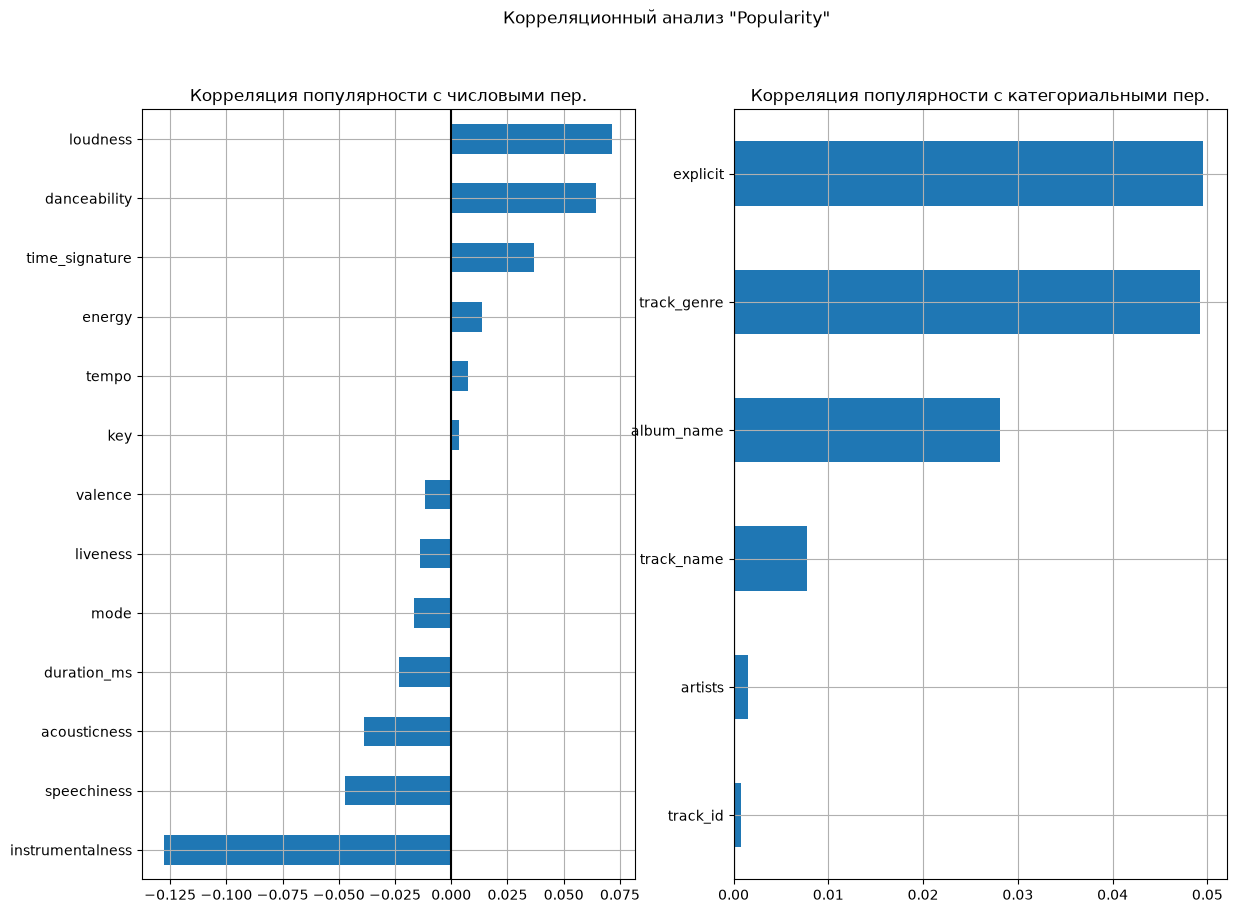

In [366]:
fig, ax = plt.subplots(1, 2, figsize=(14, 10))

corr_numbers_features.plot(
    kind='barh',
    ax=ax[0]
)
ax[0].set_title('Корреляция популярности с числовыми пер.')
ax[0].axvline(0, color='black')
ax[0].grid()



corr_spearman.plot(
    kind='barh',
    ax=ax[1]
)
ax[1].set_title('Корреляция популярности с категориальными пер.')
ax[1].axvline(0, color='black')
ax[1].grid()


plt.suptitle('Корреляционный анализ "Popularity"')
plt.show()

Выведем общую карту. Для категориальных признаков будем считать коррелцию со средней по группе.

https://www.geeksforgeeks.org/python/seaborn-heatmap-a-comprehensive-guide/

In [367]:
df_to_all_corr = df[numbers_columns_names].copy()

for column in non_numbers_columns_names:
    df_to_all_corr[column] = df[column].map(df.groupby(column)['popularity'].mean())

df_to_all_corr

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_id,artists,album_name,track_name,explicit,track_genre
0,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.210000,0.000000,0.1170,0.120,76.332,4,57.0,57.000000,57.000000,57.000000,32.861963,43.331126
1,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.905000,0.000071,0.1320,0.143,181.740,3,71.0,53.933333,71.000000,57.600000,32.861963,43.331126
2,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.469000,0.000000,0.0829,0.167,119.949,4,82.0,41.727273,39.000000,42.882353,32.861963,43.331126
3,74,189613,0.625,0.4140,0,-8.700,1,0.0369,0.294000,0.000000,0.1510,0.669,130.088,4,74.0,71.000000,74.250000,47.750000,32.861963,43.331126
4,74,244800,0.627,0.3630,8,-8.127,1,0.0291,0.279000,0.000000,0.0928,0.301,99.905,4,74.0,61.812500,60.500000,53.000000,32.861963,43.331126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89736,53,287000,0.650,0.3270,10,-11.441,1,0.0324,0.725000,0.000302,0.0824,0.196,140.047,3,53.0,52.200000,53.000000,53.000000,32.861963,49.291845
89737,0,263666,0.759,0.8430,8,-3.718,1,0.0913,0.127000,0.000000,0.1140,0.560,105.016,4,0.0,6.000000,0.000000,6.000000,32.861963,38.196474
89738,24,256839,0.585,0.8050,11,-14.211,0,0.0344,0.007390,0.000828,0.0699,0.919,131.820,4,24.0,25.666667,37.961039,24.000000,32.861963,36.144432
89739,25,125859,0.592,0.9320,1,-5.412,1,0.0558,0.000005,0.859000,0.0730,0.677,133.987,4,25.0,24.600000,25.000000,25.000000,36.887721,44.000000


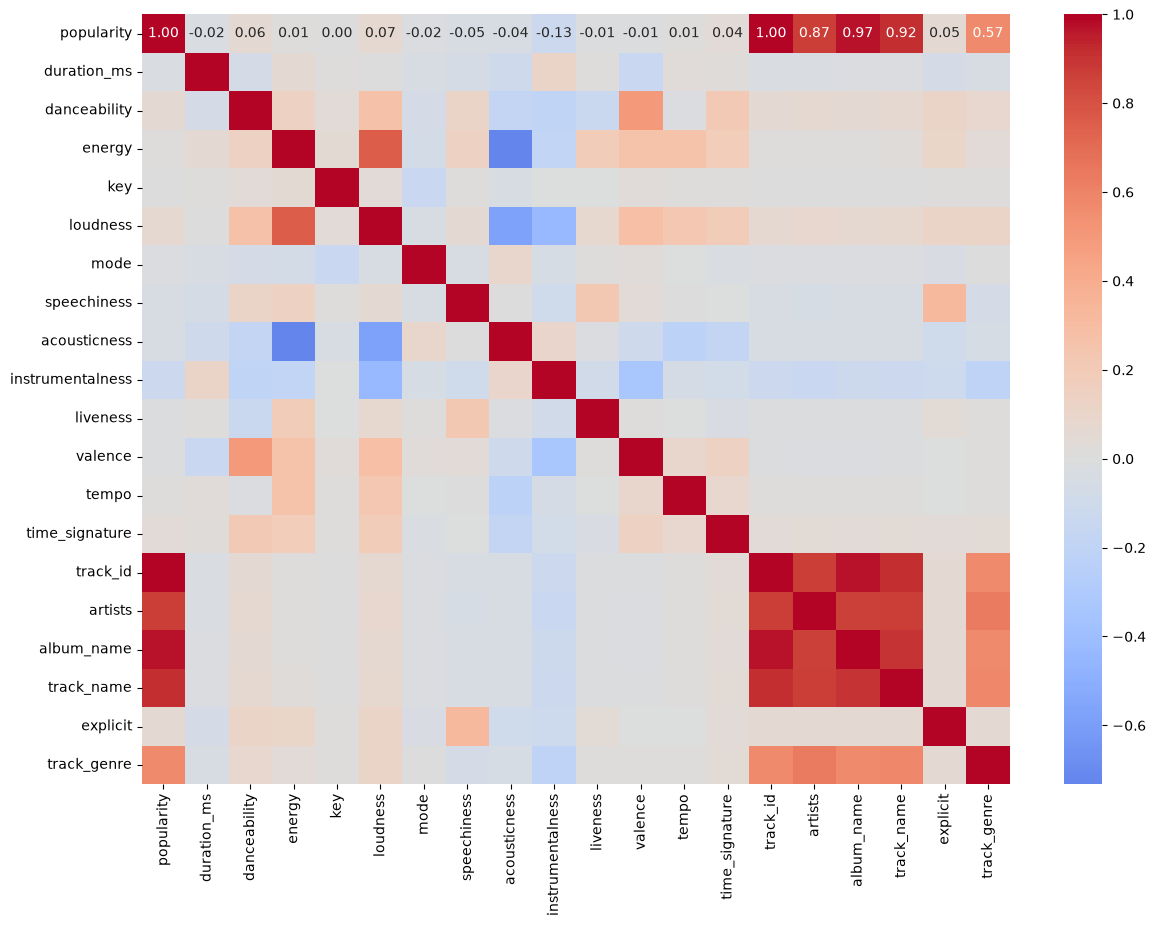

In [368]:
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_to_all_corr.corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    center=0,
    ax = ax
)
plt.show()

После корреляционного анализ можно сделать вывод, что больше всего на популярность трека влияет:
- артист
- альбом 
- жанр

**3. Построим графики по общим признакам**

Начнем с топ-20 самых популярных артистов + топ-20 самых НЕ популяных артистов. Будем считать среднюю популярность по каждому из артистов.

In [369]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [370]:
artist_mean_popularity = df.groupby('artists')['popularity'].mean().reset_index().rename(columns={'popularity': 'mean_popularity'})
artist_mean_popularity

,artists,mean_popularity
0,!nvite,23.000000
1,"""Puppy Dog Pals"" Cast",57.500000
2,"""Weird Al"" Yankovic",26.333333
3,#Kids;Nursery Rhymes;Nursery Rhymes and Kids S...,34.000000
4,$affie,39.000000
...,...,...
31432,黃仲崑,24.333333
31433,黃妃,24.000000
31434,黃小琥,56.000000
31435,黃敏華,20.000000


In [371]:
artist_mean_popularity.sort_values(by='mean_popularity').tail(20)

,artists,mean_popularity
3551,Billie Eilish;Khalid,89.0
8605,Elley Duhé,90.0
23609,Ruth B.,90.0
2866,Bad Bunny;Rauw Alejandro,90.0
24822,Shakira;Rauw Alejandro,90.0
2869,Bad Bunny;Tony Dize,90.0
27725,The Weeknd;Gesaffelstein,90.0
3155,Beach Weather,90.0
22665,Rauw Alejandro;Lyanno;Brray,91.0
16525,Luar La L,91.0


In [372]:
df['artists']

0           Ingrid Michaelson;ZAYN
1                     Kina Grannis
2                 Chord Overstreet
3        Jason Mraz;Colbie Caillat
4                     Zack Tabudlo
                   ...            
89736                 Twin Strings
89737              Jhayco;Anuel AA
89738                      Squeeze
89739                       Attila
89740            The Neighbourhood
Name: artists, Length: 89740, dtype: object

1 трек может исполнять несколько артистов - они разделены через спец. символ: ";". Проведем FE и разделим таких исполнителей на artist_1, artists_2 и тд

In [373]:
splited_artist = df['artists'].str.split(';', expand=True)
splited_artist

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,Ingrid Michaelson,ZAYN,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,Kina Grannis,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,Chord Overstreet,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,Jason Mraz,Colbie Caillat,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,Zack Tabudlo,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89736,Twin Strings,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
89737,Jhayco,Anuel AA,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
89738,Squeeze,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
89739,Attila,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [374]:
splited_artist.columns = [f'artist_{number_of_artist + 1}' for number_of_artist in range(0, splited_artist.shape[1])]
splited_artist

,artist_1,artist_2,artist_3,artist_4,artist_5,artist_6,artist_7,artist_8,artist_9,artist_10,...,artist_29,artist_30,artist_31,artist_32,artist_33,artist_34,artist_35,artist_36,artist_37,artist_38
0,Ingrid Michaelson,ZAYN,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,Kina Grannis,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,Chord Overstreet,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,Jason Mraz,Colbie Caillat,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,Zack Tabudlo,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89736,Twin Strings,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
89737,Jhayco,Anuel AA,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
89738,Squeeze,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
89739,Attila,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [375]:
df = pd.concat([df, splited_artist], axis=1)
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,artist_29,artist_30,artist_31,artist_32,artist_33,artist_34,artist_35,artist_36,artist_37,artist_38
0,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,None,None,None,None,None,None,None,None,None,None
1,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,None,None,None,None,None,None,None,None,None,None
2,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,None,None,None,None,None,None,None,None,None,None
3,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,...,None,None,None,None,None,None,None,None,None,None
4,4mzP5mHkRvGxdhdGdAH7EJ,Zack Tabudlo,Episode,Give Me Your Forever,74,244800,False,0.627,0.3630,8,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89736,7ztSVy67w9rXpKg5L2zN5l,Twin Strings,Dhalti Rahe - Single,Dhalti Rahe,53,287000,False,0.650,0.3270,10,...,None,None,None,None,None,None,None,None,None,None
89737,7zubR9uYAWjb5KPZTMm85e,Jhayco;Anuel AA,El perreo es el futuro,Ley Seca,0,263666,False,0.759,0.8430,8,...,None,None,None,None,None,None,None,None,None,None
89738,7zumacGldlmxpoP8bpaeLe,Squeeze,Greatest Hits,Slap & Tickle,24,256839,False,0.585,0.8050,11,...,None,None,None,None,None,None,None,None,None,None
89739,7zv2vmZq8OjS54BxFzI2wM,Attila,Soundtrack to a Party (Bonus),Lets Start the Party,25,125859,True,0.592,0.9320,1,...,None,None,None,None,None,None,None,None,None,None


Удалим столбец с общим названием

In [376]:
df.drop('artists', axis=1 , inplace=True)
df

,track_id,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,...,artist_29,artist_30,artist_31,artist_32,artist_33,artist_34,artist_35,artist_36,artist_37,artist_38
0,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,...,None,None,None,None,None,None,None,None,None,None
1,6lfxq3CG4xtTiEg7opyCyx,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,...,None,None,None,None,None,None,None,None,None,None
2,5vjLSffimiIP26QG5WcN2K,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,...,None,None,None,None,None,None,None,None,None,None
3,0IktbUcnAGrvD03AWnz3Q8,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,-8.700,...,None,None,None,None,None,None,None,None,None,None
4,4mzP5mHkRvGxdhdGdAH7EJ,Episode,Give Me Your Forever,74,244800,False,0.627,0.3630,8,-8.127,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89736,7ztSVy67w9rXpKg5L2zN5l,Dhalti Rahe - Single,Dhalti Rahe,53,287000,False,0.650,0.3270,10,-11.441,...,None,None,None,None,None,None,None,None,None,None
89737,7zubR9uYAWjb5KPZTMm85e,El perreo es el futuro,Ley Seca,0,263666,False,0.759,0.8430,8,-3.718,...,None,None,None,None,None,None,None,None,None,None
89738,7zumacGldlmxpoP8bpaeLe,Greatest Hits,Slap & Tickle,24,256839,False,0.585,0.8050,11,-14.211,...,None,None,None,None,None,None,None,None,None,None
89739,7zv2vmZq8OjS54BxFzI2wM,Soundtrack to a Party (Bonus),Lets Start the Party,25,125859,True,0.592,0.9320,1,-5.412,...,None,None,None,None,None,None,None,None,None,None


Посмотрим на популярность артистов, для этого используем метод .melt: https://www.geeksforgeeks.org/python/python-pandas-melt/

In [377]:
artists_columns_names = [name for name in df.columns if 'artist_' in name]
print(artists_columns_names)

all_artists_in_line = df[artists_columns_names + ['popularity']].melt(
    id_vars = 'popularity',
    value_vars = artists_columns_names,
    value_name = 'artists'
)
all_artists_in_line

['artist_1', 'artist_2', 'artist_3', 'artist_4', 'artist_5', 'artist_6', 'artist_7', 'artist_8', 'artist_9', 'artist_10', 'artist_11', 'artist_12', 'artist_13', 'artist_14', 'artist_15', 'artist_16', 'artist_17', 'artist_18', 'artist_19', 'artist_20', 'artist_21', 'artist_22', 'artist_23', 'artist_24', 'artist_25', 'artist_26', 'artist_27', 'artist_28', 'artist_29', 'artist_30', 'artist_31', 'artist_32', 'artist_33', 'artist_34', 'artist_35', 'artist_36', 'artist_37', 'artist_38']


,popularity,variable,artists
0,57,artist_1,Ingrid Michaelson
1,71,artist_1,Kina Grannis
2,82,artist_1,Chord Overstreet
3,74,artist_1,Jason Mraz
4,74,artist_1,Zack Tabudlo
...,...,...,...
3410115,53,artist_38,None
3410116,0,artist_38,None
3410117,24,artist_38,None
3410118,25,artist_38,None


In [378]:
artist_mean_popularity = all_artists_in_line.groupby('artists')['popularity'].mean().reset_index().rename(columns={'popularity': 'mean_popularity'}).sort_values('mean_popularity', ascending=False)
artist_mean_popularity

,artists,mean_popularity
3234,Bizarrap,99.0
21043,Quevedo,99.0
10483,Harry Styles,92.0
15548,Luar La L,91.0
2766,Beach Weather,90.0
...,...,...
6300,David Fung,0.0
6296,David Devoto,0.0
6295,David DeMaría,0.0
6291,David Carretta,0.0


Теперь после группировки пострим график с топовыми исполнителями и аутсайдерами.

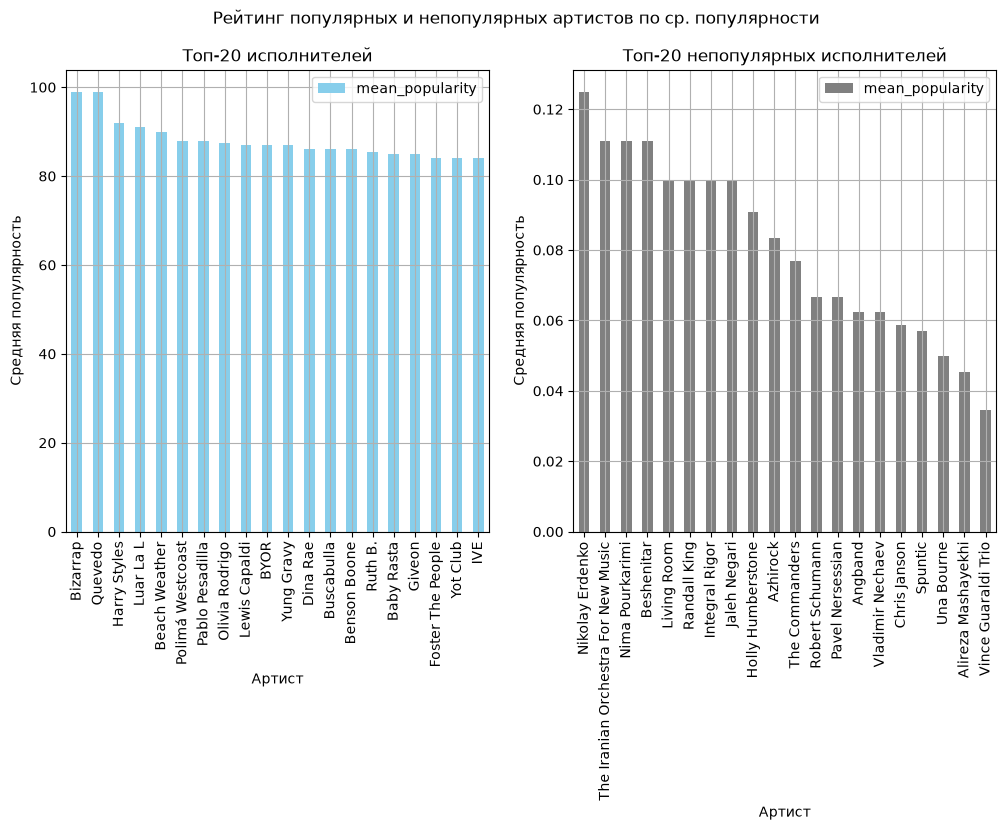

In [379]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=False)

artist_mean_popularity.head(20).plot(
    kind = 'bar',
    x = 'artists',
    y = 'mean_popularity',
    ax = ax[0],
    color = 'skyblue'
)
ax[0].set_title('Топ-20 исполнителей')
ax[0].set_xlabel('Артист')
ax[0].set_ylabel('Средняя популярность')
ax[0].grid()



artist_mean_popularity[artist_mean_popularity['mean_popularity'] > 0].tail(20).plot(
    kind = 'bar',
    x = 'artists',
    y = 'mean_popularity',
    ax = ax[1],
    color = 'grey'
)
ax[1].set_title('Топ-20 непопулярных исполнителей')
ax[1].set_xlabel('Артист')
ax[1].set_ylabel('Средняя популярность')
ax[1].set_ylim(bottom=0)
ax[1].grid()


plt.suptitle('Рейтинг популярных и непопулярных артистов по ср. популярности')
plt.show()

Самых непопулярных выведем в формате таблицы.

In [ ]:
artist_mean_popularity.tail(20)

,artists,mean_popularity
6232,Daryl Hall & John Oates,0.0
15286,Loredana Bertè,0.0
15248,London Sinfonietta,0.0
27548,Vargas & Lagola,0.0
22838,Sam & Dave,0.0
15243,London Grammar,0.0
6315,David Huntsinger,0.0
6313,David Hodges,0.0
24214,Sohrab Motabar,0.0
28956,Zooey Deschanel,0.0


Кол-во артистов с нулевой средней популярностью:

In [382]:
print(f"Общее кол-во: {len(artist_mean_popularity[artist_mean_popularity['mean_popularity'] > 0])}")

print(f"В % : {len(artist_mean_popularity[artist_mean_popularity['mean_popularity'] > 0]) / len(artist_mean_popularity)}")

Общее кол-во: 28580
В % : 0.9571653437824441


Таких исполнителей большинство.